In [1]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
from resonator import Model_fit

In [2]:
from scipy.optimize import curve_fit

In [3]:
import os

In [7]:
def resonator_fit_from_dir(dirname,fit=True):
    header = "D:/K_sunada/result/"
    dd = datadict_from_hdf5(header+dirname+"/data")
    s11 = dd['s11']['values']
    f = dd['frequency']['values'] * 1e-9
    if fit:
        result = Model_fit(f,s11)
        fig, ax = plt.subplots(1,2,figsize=(10,4))
        ax[0].plot(f, np.abs(s11), '.', color='k')
        ax[0].plot(f, np.abs(result.init_fit), '--', label='initial fit', color='orange')
        ax[0].plot(f, np.abs(result.best_fit), '-', label='best fit', color='red')
        ax[0].legend()
        ax[1].plot(f, np.angle(s11), '.', color='k')
        ax[1].plot(f, np.angle(result.init_fit), '--', label='initial fit', color='orange')
        ax[1].plot(f, np.angle(result.best_fit), '-', label='best fit', color='red')
        ax[1].legend()

        return result
    else:
        fig, ax = plt.subplots(1,2,figsize=(10,4))
        ax[0].plot(f, np.abs(s11), '.', color='k')
        ax[1].plot(f, np.angle(s11), '.', color='k')
        return f, s11, fig, ax

In [5]:
def fit_partial(ff,fs11,startf,stopf):
    id1,id2 = np.argmin(np.abs(ff-startf)),np.argmin(np.abs(ff-stopf))
    f = ff[id1:id2]
    s11 = fs11[id1:id2]
    result = Model_fit(f,s11)
    fig, ax = plt.subplots(1,2,figsize=(10,4))
    ax[0].plot(f, np.abs(s11), '.', color='k')
    ax[0].plot(f, np.abs(result.init_fit), '--', label='initial fit', color='orange')
    ax[0].plot(f, np.abs(result.best_fit), '-', label='best fit', color='red')
    ax[0].legend()
    ax[1].plot(f, np.angle(s11), '.', color='k')
    ax[1].plot(f, np.angle(result.init_fit), '--', label='initial fit', color='orange')
    ax[1].plot(f, np.angle(result.best_fit), '-', label='best fit', color='red')
    ax[1].legend()

    return result

In [7]:
dirlist = os.listdir('../database/2023-06-08/')
dirlist

FileNotFoundError: [WinError 3] The system cannot find the path specified: '../database/2023-06-08/'

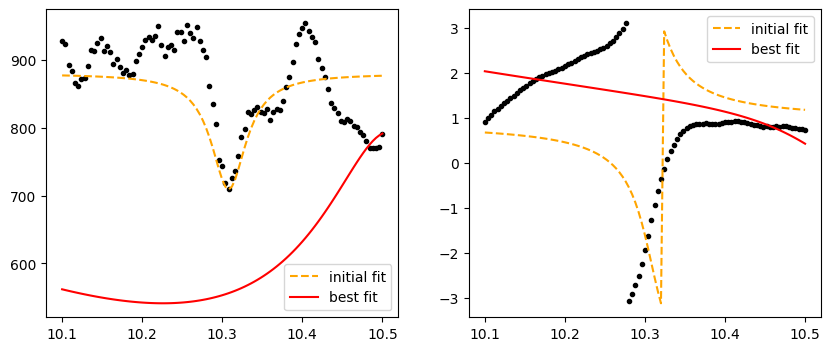

In [6]:
result = resonator_fit_from_dir('/CDY149/2023-10-09/2023-10-09T140842_ea5ae99f-td_spectrum')
result